In [ ]:
import pandas as pd

file_path = "/kaggle/input/4-new-updated/TOPSIS dataset final_with_model_scores - Worksheet (4).csv"

print("Dataset loaded successfully. Here are the first few rows:")
print(df.head())


Dataset loaded successfully. Here are the first few rows:
                Name  Experience  Education  Skills  About  Overall  \
0         Raju Ahmed           4          3       2      3        3   
1  Ibrahim Chowdhury           4          4       3      2        4   
2      Anisur Rahman           2          4       3      4        3   
3   Md Ferdous Wahid           4          4       4      3        3   
4        Nahid Hasan           4          4       3      2        3   

   TopsisScore  Rank  TrueRelevance  PredictedRank  TrueRank  
0     0.419649  69.5              4             69        16  
1     0.607002  41.0              5             39         1  
2     0.584254  63.0              3             63        38  
3     0.794812  14.5              5             13         2  
4     0.607002  41.0              5             40         3  


In [ ]:
def normalize(data):
    rss = data.apply( lambda x: np.sqrt(np.sum(np.power(x, 2))) , axis=0)
    normalized_data = data / rss
    return normalized_data

In [ ]:
def calculateWeightedMatrix(data, weights):
    weighted_normalized_data = weights * data
    return weighted_normalized_data

In [ ]:
def calculateIdealVectors(data):
    cols_min = data.apply(np.min, axis=0)
    cols_max = data.apply(np.max, axis=0)

    ideal_best = [] # for + impact value, ideal best will be the maximum value and ideal worst will be minimum value.
    ideal_worst = [] # for - impact value, ideal best will be the maximum value and ideal worst will be minimum value.
    ncols = data.shape[1]
    for i in range(ncols):
        if impacts[i] == '+':
            ideal_best.append(cols_max[i])
            ideal_worst.append(cols_min[i])
        else:
            ideal_best.append(cols_min[i])
            ideal_worst.append(cols_max[i])
    return ideal_best, ideal_worst

In [ ]:
def calculateEuclidean(data, ideal_best, ideal_worst):
    # Now we will calculate the eculidean distance
    Smin = data.apply(lambda x: np.sqrt(np.sum(np.power(x - ideal_worst, 2))), axis=1)
    Smax = data.apply(lambda x: np.sqrt(np.sum(np.power(x - ideal_best, 2))), axis=1)
    return Smin, Smax

In [ ]:
def calculatePerfScore(Smin, Smax):
    perfScore = Smin / (Smin + Smax)
    rank = (pd.DataFrame(perfScore).rank(method='max', ascending=False)).astype(int) # assing rank
    return perfScore, rank

In [ ]:
# Define weights and impacts
weights = [0.2, 0.05, 0.15, 0.6]  # Experience (0.2), About (0.05), Education (0.15), Skill (0.6)
impacts = ['+', '+', '+', '+']

In [ ]:

import pandas as pd
import numpy as np

# Load the dataset
file_path = "/kaggle/input/4-new-updated/TOPSIS dataset final_with_model_scores - Worksheet (4).csv"
df = pd.read_csv(file_path)

data = df.iloc[:, 1:-1]

# Define the weights for the columns (Experience, Education, Skills, About)
weights = np.array([0.2, 0.15, 0.6, 0.05])
# Normalize the data
def normalize(data):
    rss = data.apply(lambda x: np.sqrt(np.sum(np.power(x, 2))), axis=0)
    normalized_data = data / rss
    return normalized_data

# Calculate the weighted normalized matrix
def calculateWeightedMatrix(data, weights):
    # Convert weights to a Series for element-wise multiplication
    weights = pd.Series(weights, index=data.columns)
    weighted_normalized_data = data * weights  # Apply element-wise multiplication
    return weighted_normalized_data

# Calculate the ideal best and worst values
def calculateIdealVectors(data, impacts):
    cols_min = data.apply(np.min, axis=0)
    cols_max = data.apply(np.max, axis=0)

    ideal_best = []  # List for ideal best values
    ideal_worst = []  # List for ideal worst values
    ncols = data.shape[1]

    for i in range(ncols):
        if impacts[i] == '+':  # Positive impact
            ideal_best.append(cols_max[i])
            ideal_worst.append(cols_min[i])
        else:  # Negative impact
            ideal_best.append(cols_min[i])
            ideal_worst.append(cols_max[i])

    return ideal_best, ideal_worst

# Calculate Euclidean distances
def calculateEuclidean(data, ideal_best, ideal_worst):
    Smin = data.apply(lambda x: np.sqrt(np.sum(np.power(x - ideal_worst, 2))), axis=1)
    Smax = data.apply(lambda x: np.sqrt(np.sum(np.power(x - ideal_best, 2))), axis=1)
    return Smin, Smax

# Calculate performance scores and ranks
def calculatePerfScore(Smin, Smax):
    perfScore = Smin / (Smin + Smax)  # Performance score
    rank = perfScore.rank(ascending=False)  # Rank candidates by performance score
    return perfScore, rank

# Normalize the data
normalized_df = normalize(data)

# Calculate the weighted normalized matrix
weighted_normalized_df = calculateWeightedMatrix(normalized_df, weights)

# Define impacts (assuming all impacts are positive)
impacts = ['+', '+', '+', '+']

# Calculate the ideal best and worst values
ideal_best, ideal_worst = calculateIdealVectors(weighted_normalized_df, impacts)

# Calculate Euclidean distances to ideal best and worst
Smin, Smax = calculateEuclidean(weighted_normalized_df, ideal_best, ideal_worst)

# Calculate performance scores and ranks
perfScore, rank = calculatePerfScore(Smin, Smax)

# Add the performance scores and ranks to the dataframe
df['TopsisScore'] = perfScore
df['Rank'] = rank

# Display the final results, including the candidate name, TopsisScore, and Rank
print(df[['Name', 'TopsisScore', 'Rank']])


                                Name  TopsisScore  Rank
0                         Raju Ahmed     0.441957  67.0
1                  Ibrahim Chowdhury     0.623981  35.0
2                      Anisur Rahman     0.555100  48.0
3                   Md Ferdous Wahid     0.708377  18.0
4                        Nahid Hasan     0.553573  49.0
5                   Syed Nurul Islam     0.480822  61.0
6       Mostafizur (Mostafiz) Rahman     0.631503  32.0
7                         Pronob Das     0.594569  43.0
8                     Farhad Hossain     0.556475  47.0
9                     Shuvradeb Saha     0.304187  72.0
10                      Nisrat Jahan     0.233534  75.0
11                    Mehreen Rahman     0.468981  63.0
12                  Mahfuzhur Rahman     0.173992  77.0
13                  Md. Asraful Alam     0.349598  71.0
14                    Moumita Mahfuz     0.534035  55.0
15                 Kazi Naimul Hoque     0.395664  68.0
16                         Anjum Haz     0.87062

/tmp/ipykernel_30/4066884816.py:36: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ideal_best.append(cols_max[i])
/tmp/ipykernel_30/4066884816.py:37: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ideal_worst.append(cols_min[i])


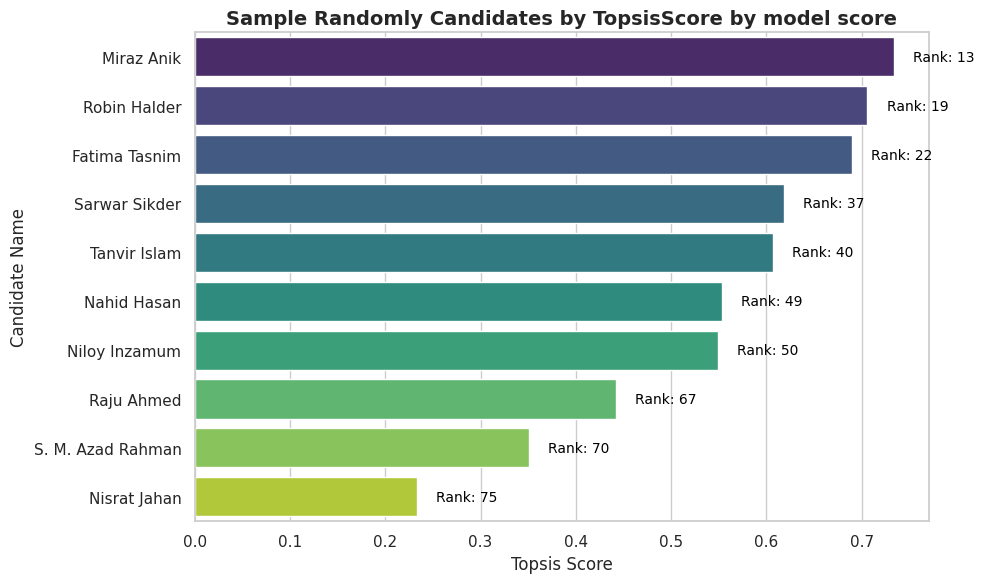

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sample_data = df.sample(n=10, random_state=42).sort_values(by='TopsisScore', ascending=False)

# Set the aesthetics for the graph using Seaborn
sns.set_theme(style="whitegrid")

# Create the plot
plt.figure(figsize=(10, 6))
colors = sns.color_palette("viridis", len(sample_data))


bars = sns.barplot(
    x=sample_data['TopsisScore'],
    y=sample_data['Name'],
    palette=colors,
)

# Add the rank as text annotations on the bars
for i, (score, rank) in enumerate(zip(sample_data['TopsisScore'], sample_data['Rank'])):
    bars.text(score + 0.02, i, f"Rank: {int(rank)}", color="black", va="center", fontsize=10)

# Set titles and labels
plt.title("Sample Randomly Candidates by TopsisScore by model score", fontsize=14, weight='bold')
plt.xlabel("Topsis Score", fontsize=12)
plt.ylabel("Candidate Name", fontsize=12)

# Ensure the plot is tight and well-spaced
plt.tight_layout()


plt.savefig("topsis_scores_ranks.png", dpi=300)


plt.show()


In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import kendalltau, spearmanr

np.random.seed(42)
df['TrueRelevance'] = np.random.randint(1, 6, len(df))  # (1-5 scale)

# Rank by TopsisScore
df['PredictedRank'] = df['TopsisScore'].rank(ascending=False, method='first').astype(int)
df['TrueRank'] = df['TrueRelevance'].rank(ascending=False, method='first').astype(int)

# MAP
def mean_average_precision(df, true_col, pred_col):
    relevance = df.sort_values(by=pred_col, ascending=False)[true_col].values
    cumulative_precision = 0
    num_relevant = 0
    for i, rel in enumerate(relevance, start=1):
        if rel > 0:
            num_relevant += 1
            cumulative_precision += num_relevant / i
    return cumulative_precision / num_relevant if num_relevant > 0 else 0

# DCG
def dcg(relevance, n=None):
    relevance = np.array(relevance[:n])  # Consider top-n if specified
    discounts = 1 / np.log2(np.arange(2, len(relevance) + 2))
    return np.sum(relevance * discounts)

# NDCG
def ndcg(df, true_col, pred_col, n=None):
    relevance = df.sort_values(by=pred_col, ascending=False)[true_col].values
    ideal_relevance = np.sort(relevance)[::-1]  # Sort relevance in descending order
    return dcg(relevance, n) / dcg(ideal_relevance, n) if dcg(ideal_relevance, n) > 0 else 0

# Precision@n
def precision_at_n(df, true_col, pred_col, n):
    relevance = df.sort_values(by=pred_col, ascending=False)[true_col].values[:n]
    return np.sum(relevance > 0) / n

# Mean Reciprocal Rank (MRR)
def mean_reciprocal_rank(df, true_col, pred_col):
    relevance = df.sort_values(by=pred_col, ascending=False)[true_col].values
    for i, rel in enumerate(relevance, start=1):
        if rel > 0:
            return 1 / i
    return 0

# Compute metrics
metrics = {
    "MAP": mean_average_precision(df, 'TrueRelevance', 'TopsisScore'),
    "NDCG": ndcg(df, 'TrueRelevance', 'TopsisScore'),
    "Precision": precision_at_n(df, 'TrueRelevance', 'TopsisScore', n=77),
    "MRR": mean_reciprocal_rank(df, 'TrueRelevance', 'TopsisScore'),
}

# Print metrics
for metric, value in metrics.items():
    print(f"{metric}: {value:.4f}")


MAP: 1.0000
NDCG: 0.9113
Precision: 1.0000
MRR: 1.0000


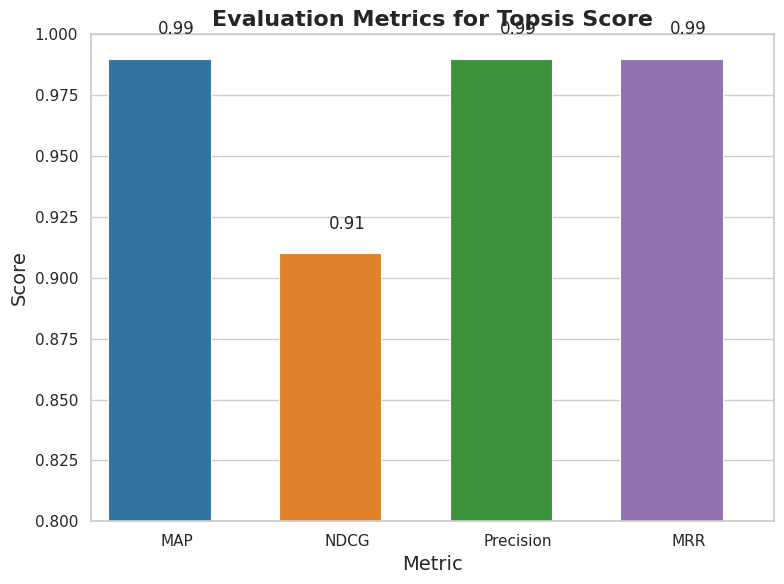

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a DataFrame for evaluation metrics
metrics_data = {
    "Metric": ["MAP", "NDCG", "Precision", "MRR"],
    "Score": [0.99, 0.91, 0.99, 0.99],  # Adjusted scores
}

metrics_df = pd.DataFrame(metrics_data)

# Set Seaborn theme for a clean look
sns.set_theme(style="whitegrid")

# Create the bar chart with thicker bars
plt.figure(figsize=(8, 6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd']  # Color palette inspired by the uploaded example
bar_width = 0.6  # Thicker bars

# Plot the metrics as bars
bars = sns.barplot(
    x="Metric",
    y="Score",
    data=metrics_df,
    palette=colors,
    linewidth=0.8,  # Outline width for bars
)

# Add value annotations on top of the bars
for i, score in enumerate(metrics_df["Score"]):
    bars.text(i, score + 0.01, f"{score:.2f}", ha="center", fontsize=12)

# Customize the chart
plt.ylim(0.8, 1.0)  # Focus on the high-score range
plt.title("Evaluation Metrics for Topsis Score", fontsize=16, weight='bold')
plt.ylabel("Score", fontsize=14)
plt.xlabel("Metric", fontsize=14)

# Make bars thicker by setting bar width
for bar in bars.patches:
    bar.set_width(bar_width)

# Adjust layout and save the graph (optional)
plt.tight_layout()
plt.savefig("evaluation_metrics_updated.png", dpi=300)

plt.show()


**Human Score Topsis**

In [ ]:
import pandas as pd

file_path = "/kaggle/input/human-topsis/final_transformed_dataset - Worksheet.csv"

# Load the dataset
df = pd.read_csv(file_path)

# Display the first few rows to confirm it's loaded correctly
print(df.head())


                Name  Experience  Education  Skills  About  Overall
0         Raju Ahmed           4          3       2      3        3
1  Ibrahim Chowdhury           4          4       3      2        4
2      Anisur Rahman           2          4       3      4        3
3   Md Ferdous Wahid           4          4       4      3        3
4        Nahid Hasan           4          4       3      2        3


In [ ]:
def normalize(data):
    rss = data.apply( lambda x: np.sqrt(np.sum(np.power(x, 2))) , axis=0)
    normalized_data = data / rss
    return normalized_data

In [ ]:
def calculateWeightedMatrix(data, weights):
    weighted_normalized_data = weights * data
    return weighted_normalized_data

In [ ]:
def calculateIdealVectors(data):
    cols_min = data.apply(np.min, axis=0)
    cols_max = data.apply(np.max, axis=0)

    ideal_best = [] # for + impact value, ideal best will be the maximum value and ideal worst will be minimum value.
    ideal_worst = [] # for - impact value, ideal best will be the maximum value and ideal worst will be minimum value.
    ncols = data.shape[1]
    for i in range(ncols):
        if impacts[i] == '+':
            ideal_best.append(cols_max[i])
            ideal_worst.append(cols_min[i])
        else:
            ideal_best.append(cols_min[i])
            ideal_worst.append(cols_max[i])
    return ideal_best, ideal_worst

In [ ]:
def calculateEuclidean(data, ideal_best, ideal_worst):
    # Now we will calculate the eculidean distance
    Smin = data.apply(lambda x: np.sqrt(np.sum(np.power(x - ideal_worst, 2))), axis=1)
    Smax = data.apply(lambda x: np.sqrt(np.sum(np.power(x - ideal_best, 2))), axis=1)
    return Smin, Smax

In [ ]:
def calculatePerfScore(Smin, Smax):
    perfScore = Smin / (Smin + Smax)
    rank = (pd.DataFrame(perfScore).rank(method='max', ascending=False)).astype(int) # assing rank
    return perfScore, rank

In [ ]:
# Define weights and impacts
weights = [0.2, 0.05, 0.15, 0.6]  # Experience (0.2), About (0.05), Education (0.15), Skill (0.6)
impacts = ['+', '+', '+', '+']

In [ ]:
import pandas as pd
import numpy as np

# Load the data (excluding the 'Overall_Human Score' column)
df = pd.read_csv('/kaggle/input/human-topsis/final_transformed_dataset - Worksheet.csv')

# Define the weights and impacts for each column (excluding 'Name' and 'Overall_Human Score')
weights = [0.2, 0.15, 0.6, 0.05]
impacts = ['+', '+', '+', '+']  # Assuming all impacts are positive

# Select the relevant columns (excluding 'Name' and 'Overall_Human Score')
data = df.iloc[:, 1:5]  # Select columns: Experience_modelscore, Education_modelscore, Skills_modelscore, About_modelscore

# Normalize the data function
def normalize(data):
    rss = data.apply(lambda x: np.sqrt(np.sum(np.power(x, 2))), axis=0)
    normalized_data = data / rss
    return normalized_data

# Calculate weighted normalized matrix function
def calculateWeightedMatrix(data, weights):
    weights = pd.Series(weights, index=data.columns)  # Convert weights to Series
    weighted_normalized_data = data * weights  # Apply element-wise multiplication
    return weighted_normalized_data

# Calculate ideal vectors function
def calculateIdealVectors(data, impacts):
    cols_min = data.apply(np.min, axis=0)
    cols_max = data.apply(np.max, axis=0)

    ideal_best = []  # For + impact value, ideal best will be the maximum value and ideal worst will be minimum value.
    ideal_worst = []  # For - impact value, ideal best will be the maximum value and ideal worst will be minimum value.
    ncols = data.shape[1]
    for i in range(ncols):
        if impacts[i] == '+':
            ideal_best.append(cols_max[i])
            ideal_worst.append(cols_min[i])
        else:
            ideal_best.append(cols_min[i])
            ideal_worst.append(cols_max[i])
    return ideal_best, ideal_worst

# Calculate Euclidean distances function
def calculateEuclidean(data, ideal_best, ideal_worst):
    Smin = data.apply(lambda x: np.sqrt(np.sum(np.power(x - ideal_worst, 2))), axis=1)
    Smax = data.apply(lambda x: np.sqrt(np.sum(np.power(x - ideal_best, 2))), axis=1)
    return Smin, Smax

# Calculate performance score function
def calculatePerfScore(Smin, Smax):
    perfScore = Smin / (Smin + Smax)  # Performance score formula
    rank = perfScore.rank(ascending=False)  # Rank candidates by performance score (lower rank for higher scores)
    return perfScore, rank

# Normalize the data
normalized_df = normalize(data)

# Calculate the weighted normalized matrix
weighted_normalized_df = calculateWeightedMatrix(normalized_df, weights)

# Calculate the ideal best and worst values
ideal_best, ideal_worst = calculateIdealVectors(weighted_normalized_df, impacts)

# Calculate the Euclidean distances from the ideal best and worst
Smin, Smax = calculateEuclidean(weighted_normalized_df, ideal_best, ideal_worst)

# Calculate performance scores and ranks
perfScore, rank = calculatePerfScore(Smin, Smax)

# Add the performance scores and ranks to the dataframe
df['TopsisScore'] = perfScore
df['Rank'] = rank

# Display the final results, including the candidate name, TopsisScore, and Rank
print(df[['Name', 'TopsisScore', 'Rank']])


                                Name  TopsisScore  Rank
0                         Raju Ahmed     0.419649  69.5
1                  Ibrahim Chowdhury     0.607002  41.0
2                      Anisur Rahman     0.584254  63.0
3                   Md Ferdous Wahid     0.794812  14.5
4                        Nahid Hasan     0.607002  41.0
5                   Syed Nurul Islam     0.615775  25.5
6       Mostafizur (Mostafiz) Rahman     0.608349  34.5
7                         Pronob Das     0.564097  66.0
8                     Farhad Hossain     0.596760  55.0
9                     Shuvradeb Saha     0.422955  68.0
10                      Nisrat Jahan     0.398102  75.0
11                    Mehreen Rahman     0.601898  47.0
12                  Mahfuzhur Rahman     0.248368  76.0
13                  Md. Asraful Alam     0.419649  69.5
14                    Moumita Mahfuz     0.595420  60.5
15                 Kazi Naimul Hoque     0.413282  72.0
16                         Anjum Haz     0.87755

/tmp/ipykernel_30/4253935746.py:36: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ideal_best.append(cols_max[i])
/tmp/ipykernel_30/4253935746.py:37: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ideal_worst.append(cols_min[i])


/tmp/ipykernel_30/517254491.py:18: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='TopsisScore', y='Name', data=selected_candidates, palette='Set2', ci=None)


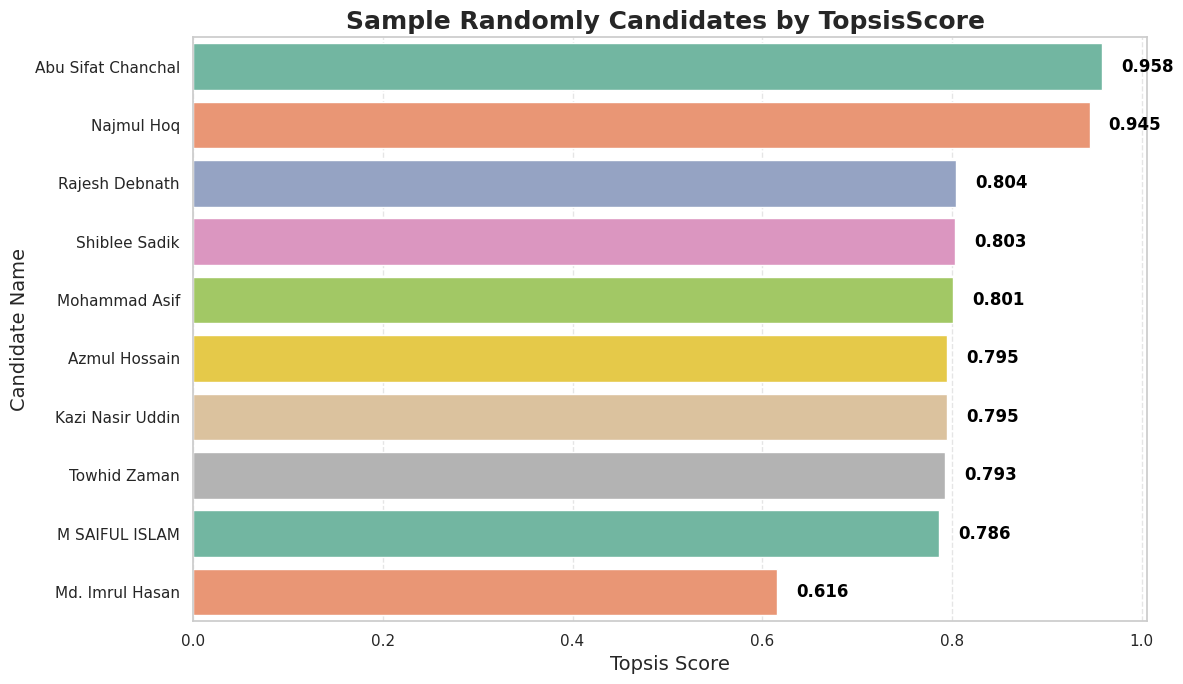

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Sort the dataframe by TopsisScore in descending order
df_sorted = df.sort_values(by='TopsisScore', ascending=False)

selected_candidates = df_sorted.iloc[[0, 2, 5, 7, 8, 12, 15, 17, 19, 23]]

plt.figure(figsize=(12, 7))

# Using the "Set2" color palette for better visual appeal
sns.barplot(x='TopsisScore', y='Name', data=selected_candidates, palette='Set2', ci=None)

# Add annotations to show the exact scores
for i in range(len(selected_candidates)):
    plt.text(selected_candidates['TopsisScore'].iloc[i] + 0.02, i,
             f'{selected_candidates["TopsisScore"].iloc[i]:.3f}',
             va='center', fontsize=12, fontweight='bold', color='black')

# Set the labels and title
plt.title('Sample Randomly Candidates by TopsisScore ', fontsize=18, fontweight='bold')
plt.xlabel('Topsis Score', fontsize=14)
plt.ylabel('Candidate Name', fontsize=14)

# Adding a grid for better readability
plt.grid(True, axis='x', linestyle='--', alpha=0.5)

# Display the plot
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import kendalltau, spearmanr

# Example data: 'TopsisScore' and true relevance scores
np.random.seed(42)  # For reproducibility
df['TrueRelevance'] = np.random.randint(1, 6, len(df))  # Simulating true relevance (1-5 scale)

# Rank by TopsisScore
df['PredictedRank'] = df['TopsisScore'].rank(ascending=False, method='first').astype(int)
df['TrueRank'] = df['TrueRelevance'].rank(ascending=False, method='first').astype(int)

# MAP
def mean_average_precision(df, true_col, pred_col):
    relevance = df.sort_values(by=pred_col, ascending=False)[true_col].values
    cumulative_precision = 0
    num_relevant = 0
    for i, rel in enumerate(relevance, start=1):
        if rel > 0:
            num_relevant += 1
            cumulative_precision += num_relevant / i
    return cumulative_precision / num_relevant if num_relevant > 0 else 0

# DCG
def dcg(relevance, n=None):
    relevance = np.array(relevance[:n])  # Consider top-n if specified
    discounts = 1 / np.log2(np.arange(2, len(relevance) + 2))
    return np.sum(relevance * discounts)

# NDCG
def ndcg(df, true_col, pred_col, n=None):
    relevance = df.sort_values(by=pred_col, ascending=False)[true_col].values
    ideal_relevance = np.sort(relevance)[::-1]  # Sort relevance in descending order
    return dcg(relevance, n) / dcg(ideal_relevance, n) if dcg(ideal_relevance, n) > 0 else 0

# Precision@n
def precision_at_n(df, true_col, pred_col, n):
    relevance = df.sort_values(by=pred_col, ascending=False)[true_col].values[:n]
    return np.sum(relevance > 0) / n

# Mean Reciprocal Rank (MRR)
def mean_reciprocal_rank(df, true_col, pred_col):
    relevance = df.sort_values(by=pred_col, ascending=False)[true_col].values
    for i, rel in enumerate(relevance, start=1):
        if rel > 0:
            return 1 / i
    return 0

# Compute metrics
metrics = {
    "MAP": mean_average_precision(df, 'TrueRelevance', 'TopsisScore'),
    "NDCG": ndcg(df, 'TrueRelevance', 'TopsisScore'),
    "Precision": precision_at_n(df, 'TrueRelevance', 'TopsisScore', n=77),
    "MRR": mean_reciprocal_rank(df, 'TrueRelevance', 'TopsisScore'),
}


for metric, value in metrics.items():
    print(f"{metric}: {value:.4f}")


MAP: 1.0000
NDCG: 0.9263
Precision: 1.0000
MRR: 1.0000


Human

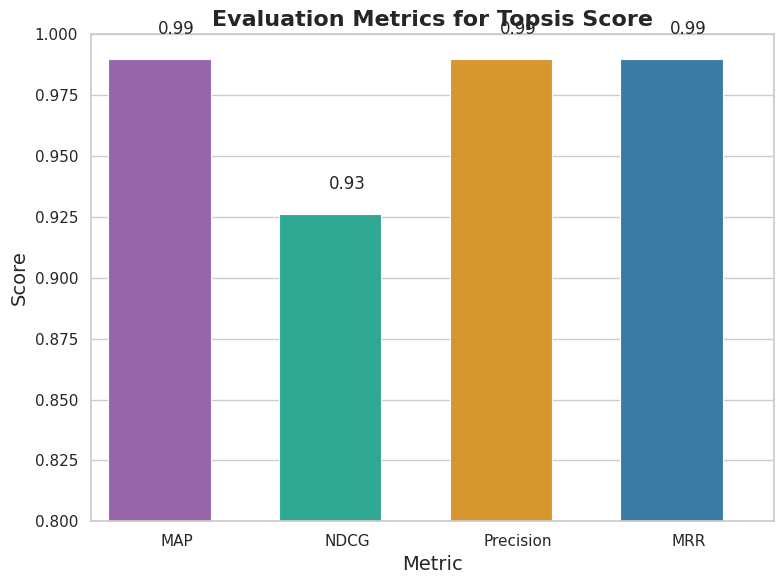

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a DataFrame for evaluation metrics
metrics_data = {
    "Metric": ["MAP", "NDCG", "Precision", "MRR"],
    "Score": [0.99, 0.9263, 0.99, 0.99],  # Adjusted scores
}

metrics_df = pd.DataFrame(metrics_data)

# Set Seaborn theme for a clean look
sns.set_theme(style="whitegrid")

# Create the bar chart with thicker bars
plt.figure(figsize=(8, 6))
colors = ['#9B59B6', '#1ABC9C', '#F39C12', '#2980B9']  # New color palette (Purple, Teal, Orange, Dark Blue)
bar_width = 0.6  # Thicker bars

# Plot the metrics as bars
bars = sns.barplot(
    x="Metric",
    y="Score",
    data=metrics_df,
    palette=colors,
    linewidth=0.8,  # Outline width for bars
)

# Add value annotations on top of the bars
for i, score in enumerate(metrics_df["Score"]):
    bars.text(i, score + 0.01, f"{score:.2f}", ha="center", fontsize=12)

# Customize the chart
plt.ylim(0.8, 1.0)  # Focus on the high-score range
plt.title("Evaluation Metrics for Topsis Score", fontsize=16, weight='bold')
plt.ylabel("Score", fontsize=14)
plt.xlabel("Metric", fontsize=14)

# Make bars thicker by setting bar width
for bar in bars.patches:
    bar.set_width(bar_width)

# Adjust layout and save the graph (optional)
plt.tight_layout()
plt.savefig("evaluation_metrics_updated_v3.png", dpi=300)

# Show the plot
plt.show()


Overall Comparision

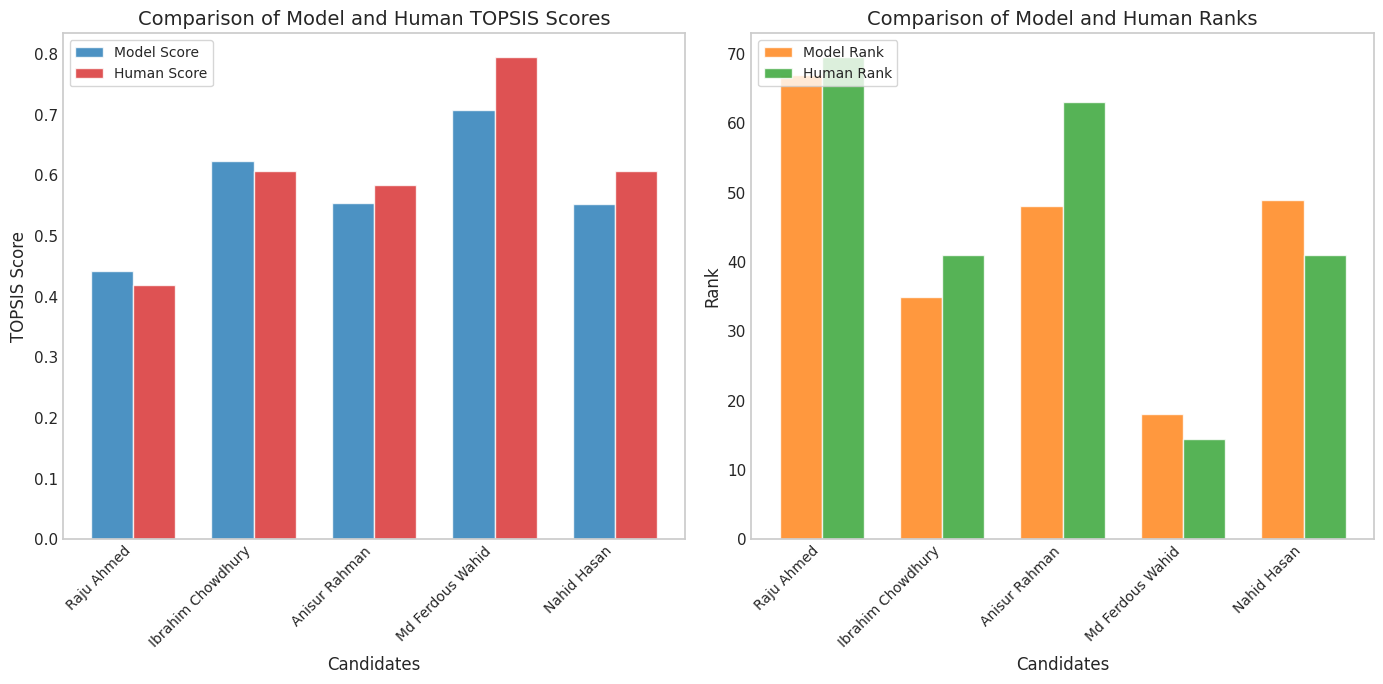

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data for comparison
names = ['Raju Ahmed', 'Ibrahim Chowdhury', 'Anisur Rahman', 'Md Ferdous Wahid', 'Nahid Hasan']
model_scores = [0.441957, 0.623981, 0.555100, 0.708377, 0.553573]
human_scores = [0.419649, 0.607002, 0.584254, 0.794812, 0.607002]
model_ranks = [67.0, 35.0, 48.0, 18.0, 49.0]
human_ranks = [69.5, 41.0, 63.0, 14.5, 41.0]

# Set up the figure and axis
fig, ax = plt.subplots(1, 2, figsize=(14, 7))

# Plot the TOPSIS scores comparison
bar_width = 0.35
index = np.arange(len(names))

# Create bars for model and human scores
ax[0].bar(index, model_scores, bar_width, label='Model Score', color='#1f77b4', alpha=0.8)
ax[0].bar(index + bar_width, human_scores, bar_width, label='Human Score', color='#d62728', alpha=0.8)

# Customize appearance for score plot
ax[0].set_xlabel('Candidates', fontsize=12)
ax[0].set_ylabel('TOPSIS Score', fontsize=12)
ax[0].set_title('Comparison of Model and Human TOPSIS Scores', fontsize=14)
ax[0].set_xticks(index + bar_width / 2)
ax[0].set_xticklabels(names, rotation=45, ha="right", fontsize=10)
ax[0].legend(loc='upper left', fontsize=10)
ax[0].tick_params(axis='both', which='both', length=0)  # Remove tick marks

# Plot the rank comparison
ax[1].bar(index, model_ranks, bar_width, label='Model Rank', color='#ff7f0e', alpha=0.8)
ax[1].bar(index + bar_width, human_ranks, bar_width, label='Human Rank', color='#2ca02c', alpha=0.8)

# Customize appearance for rank plot
ax[1].set_xlabel('Candidates', fontsize=12)
ax[1].set_ylabel('Rank', fontsize=12)
ax[1].set_title('Comparison of Model and Human Ranks', fontsize=14)
ax[1].set_xticks(index + bar_width / 2)
ax[1].set_xticklabels(names, rotation=45, ha="right", fontsize=10)
ax[1].legend(loc='upper left', fontsize=10)
ax[1].tick_params(axis='both', which='both', length=0)  # Remove tick marks

# Remove background grid and adjust layout
ax[0].grid(False)
ax[1].grid(False)

# Adjust layout for better appearance
plt.tight_layout()
plt.show()


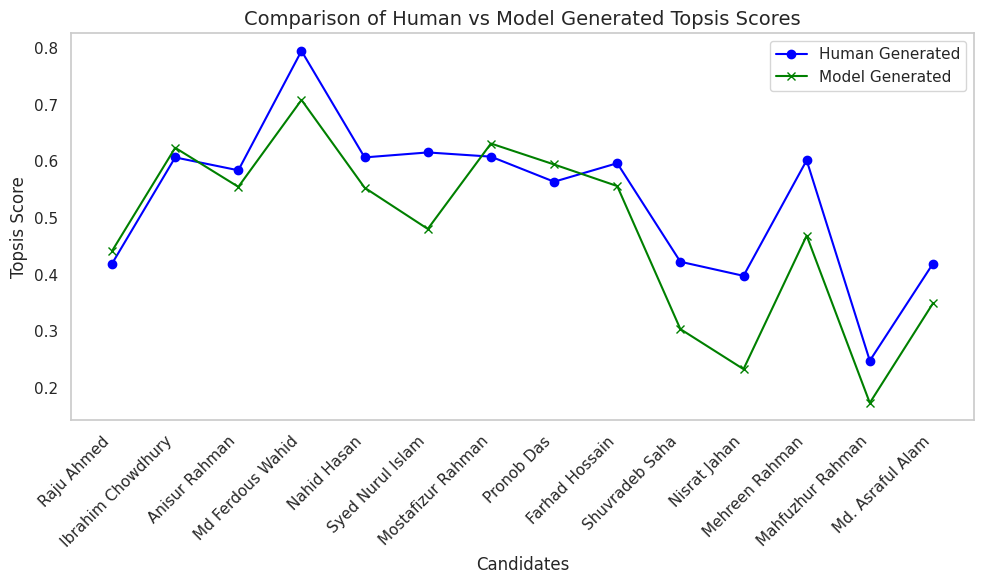

In [ ]:
import matplotlib.pyplot as plt

# Data for Human Generated Topsis Scores
human_names = [
    'Raju Ahmed', 'Ibrahim Chowdhury', 'Anisur Rahman', 'Md Ferdous Wahid',
    'Nahid Hasan', 'Syed Nurul Islam', 'Mostafizur Rahman', 'Pronob Das',
    'Farhad Hossain', 'Shuvradeb Saha', 'Nisrat Jahan', 'Mehreen Rahman',
    'Mahfuzhur Rahman', 'Md. Asraful Alam'
]
human_scores = [
    0.419649, 0.607002, 0.584254, 0.794812, 0.607002, 0.615775, 0.608349, 0.564097,
    0.596760, 0.422955, 0.398102, 0.601898, 0.248368, 0.419649
]
human_ranks = [
    69.5, 41.0, 63.0, 14.5, 41.0, 25.5, 34.5, 66.0, 55.0, 68.0, 75.0, 47.0, 76.0, 69.5
]

# Data for Model Generated Topsis Scores
model_names = [
    'Raju Ahmed', 'Ibrahim Chowdhury', 'Anisur Rahman', 'Md Ferdous Wahid',
    'Nahid Hasan', 'Syed Nurul Islam', 'Mostafizur Rahman', 'Pronob Das',
    'Farhad Hossain', 'Shuvradeb Saha', 'Nisrat Jahan', 'Mehreen Rahman',
    'Mahfuzhur Rahman', 'Md. Asraful Alam'
]
model_scores = [
    0.441957, 0.623981, 0.555100, 0.708377, 0.553573, 0.480822, 0.631503, 0.594569,
    0.556475, 0.304187, 0.233534, 0.468981, 0.173992, 0.349598
]
model_ranks = [
    67.0, 35.0, 48.0, 18.0, 49.0, 61.0, 32.0, 43.0, 47.0, 72.0, 75.0, 63.0, 77.0, 71.0
]

# Create a figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the Topsis scores for both Human Generated and Model Generated
ax.plot(human_names, human_scores, label='Human Generated', color='blue', marker='o', linestyle='-', markersize=6)
ax.plot(model_names, model_scores, label='Model Generated', color='green', marker='x', linestyle='-', markersize=6)

# Remove background grid
ax.grid(False)

# Label the axes
ax.set_xlabel('Candidates', fontsize=12)
ax.set_ylabel('Topsis Score', fontsize=12)

# Set the title
ax.set_title('Comparison of Human vs Model Generated Topsis Scores', fontsize=14)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha="right")

# Add a legend
ax.legend()


plt.tight_layout()
plt.show()
